In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

GenerationReport(requested=50, generated=50, failed=0, total_attempts=51, failure_reasons={'shape_placement_failed': 1}, parameter_ranges={'fill_fraction': (0.0555877685546875, 0.51007080078125)}, metadata={'generator': 'RandomUnitCellGenerator', 'generated_at': '2026-04-12T10:04:02', 'canvas': 'Canvas(Lx=1, Ly=1, H=256, W=256, xc=0.0, yc=0.0, spacing=0)', 'config': {'seed': 40, 'target_count': 50, 'max_tries_per_shape': 100, 'max_tries_per_cell': 100, 'fixed_num_shapes': 2, 'min_num_shapes': 1, 'max_num_shapes': 3, 'allowed_shapes': ('ConvexQuad',), 'shape_weights': {}, 'fixed_shape_params': {'ConvexQuad': {'corner_radius': 0.0}}, 'shape_param_ranges': {'Rectangle': {'size': ((200, 250), (100, 150)), 'n': (3, 8)}}, 'fixed_canvas_Lx': 1.0, 'fixed_canvas_Ly': 1.0, 'canvas_Lx_range': None, 'canvas_Ly_range': None, 'min_shape_size': 0.05, 'min_feature_size': 0.05, 'min_gap': 0.0, 'extra': {}, 'require_nonempty_after_clip': True}})
50


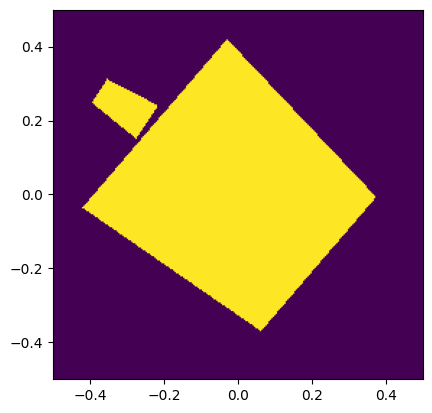

In [48]:
from metashapes.generators.random import RandomGeneratorConfig, RandomUnitCellGenerator
from metashapes.generators.validator import DefaultUnitCellValidator
from metashapes.canvas import Canvas
from metashapes.analysis import UnitCellAnalyzer
from metashapes.adapters import save_batch_result, load_batch_result

cfg = RandomGeneratorConfig(
    target_count=50,
    fixed_num_shapes=2,
    allowed_shapes=("ConvexQuad",),
    min_shape_size=0.05,
    min_feature_size=0.05,
    min_gap=0.0,
    seed=40,
    max_tries_per_cell=100,
    max_tries_per_shape=100,
    fixed_shape_params={
        "ConvexQuad": {
            #"center": (0, 0),
            #"size": (0.5, 0.5),
            'corner_radius': 0.0,
            #"angle": 30,
        },
        
    },
    shape_param_ranges={
        "Rectangle": {
            "size": ((200, 250), (100, 150)),
            #"angle": (0, 90),
            "n": (3, 8),
        }},
    fixed_canvas_Lx=1.0,
    fixed_canvas_Ly=1.0#(0.5, 2.0)
)

canvas = Canvas(Lx=1, Ly=1, W=256, H=256, spacing=0)

gen = RandomUnitCellGenerator(cfg, validator=DefaultUnitCellValidator())
result = gen.generate(canvas)

print(result.report)
print(len(result.unit_cells))

plt.imshow(result.unit_cells[0].mask_numpy(), origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))
#result.unit_cells[2].to_shapely()

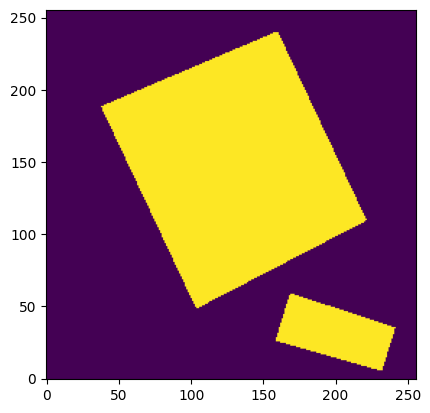

In [61]:
plt.imshow(result.unit_cells[18].mask_numpy(), origin='lower')

In [6]:
from metashapes.generators.samplers.utils import get_all_fixed_param, inspect_class_params, get_param_range
from metashapes.shape.primitives import Rectangle

names = inspect_class_params(Rectangle)
get_param_range(cfg, shape_name='Rectangle', param_name='size')

((200, 250), (100, 150))

In [35]:
result_stripe = result

In [36]:
from metashapes.generators.report import GenerationBatchResult
combined = GenerationBatchResult.merge(result_rect_sharp, result_rect, result_poly_sharp, result_poly, result_ellipse, result_stripe)

In [40]:
combined.unit_cells[30000]

UnitCell(Stripe(offset=0.3770684266586555, width=0.37137555406789674, axis='x'), Canvas(Lx=1.0, Ly=1.187910064080592, H=256, W=256, xc=0.0, yc=0.0, spacing=0), periodic_shifts={(-1, 0), (1, 0)})

In [41]:
save_batch_result("rect_poly_elli_stripe_35k.yaml", combined)

In [7]:
results_new = load_batch_result("rectangles_10k.yaml")

In [8]:
len(results_new.unit_cells)

10000

In [20]:
analyzer = UnitCellAnalyzer()
#metrics = analyzer.analyze(result.unit_cells)
analyzer.find_duplicates(result.unit_cells)

[]

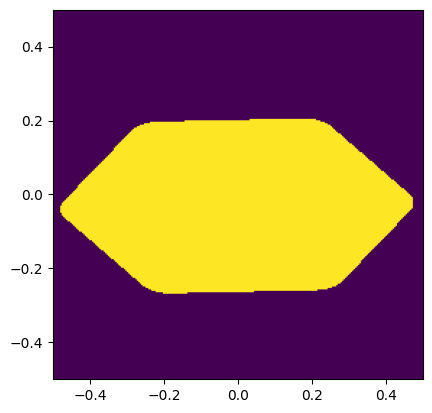

In [27]:
plt.imshow(result.unit_cells[800].mask_numpy(), origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))

(array([511., 483., 493., 500., 536., 495., 474., 532., 506., 470.]),
 array([0.5003613 , 0.65031007, 0.80025884, 0.95020761, 1.10015638,
        1.25010515, 1.40005392, 1.55000268, 1.69995145, 1.84990022,
        1.99984899]),
 <BarContainer object of 10 artists>)

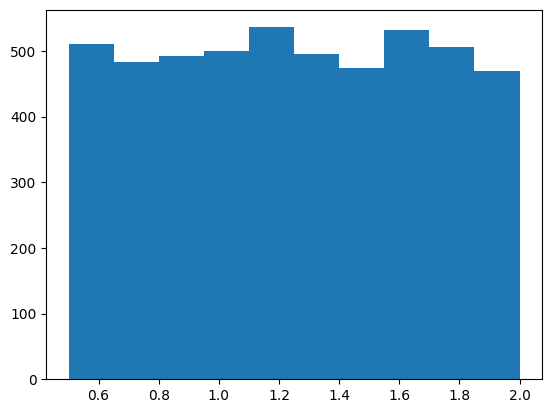

In [32]:
plt.hist([uc.canvas.Ly for uc in result.unit_cells])

(array([979., 984., 935., 813., 758., 196., 163., 102.,  51.,  19.]),
 array([0.05016254, 0.2398764 , 0.42959025, 0.61930411, 0.80901797,
        0.99873182, 1.18844568, 1.37815954, 1.56787339, 1.75758725,
        1.9473011 ]),
 <BarContainer object of 10 artists>)

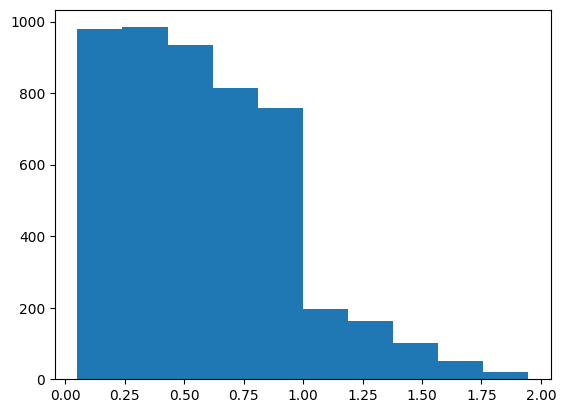

In [34]:
plt.hist([uc.shape.width for uc in result.unit_cells])

(array([812.,   0., 815.,   0., 873.,   0., 831.,   0., 813., 856.]),
 array([3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ]),
 <BarContainer object of 10 artists>)

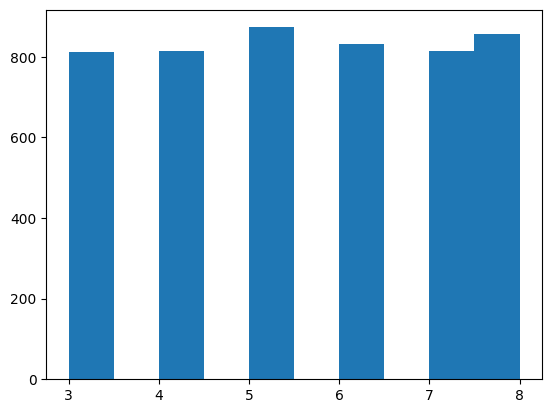

In [22]:
plt.hist([uc.shape.n for uc in result.unit_cells])

(array([782., 501., 280., 171., 117.,  81.,  33.,  21.,  12.,   2.]),
 array([1.41386509e-04, 3.75377477e-02, 7.49341090e-02, 1.12330470e-01,
        1.49726831e-01, 1.87123193e-01, 2.24519554e-01, 2.61915915e-01,
        2.99312276e-01, 3.36708638e-01, 3.74104999e-01]),
 <BarContainer object of 10 artists>)

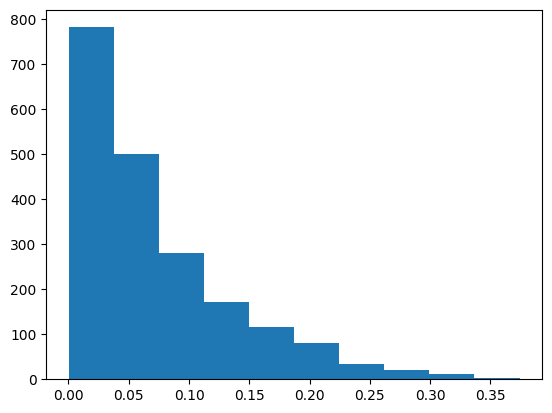

In [52]:
plt.hist([uc.shape.corner_radius for uc in result.unit_cells])

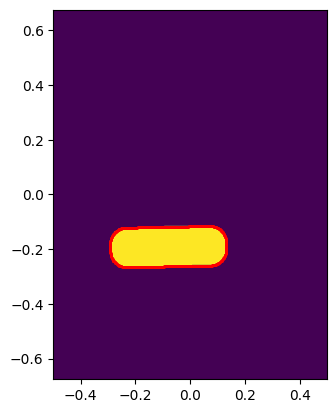

In [51]:
fig, ax = plt.subplots()

# show the mask
cell = result.unit_cells[30]

c = cell.canvas
plt.imshow(cell.mask_numpy(), origin='lower',
           extent=(c.x0, c.x1, c.y0, c.y1))
# overlay boundary points
pts = cell.boundary_points()  # shape (N, 2) in physical coords
ax.scatter(pts[:, 0], pts[:, 1], s=1, c='red')

plt.show()

/Users/rodionsa/mambaforge/envs/shapes/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


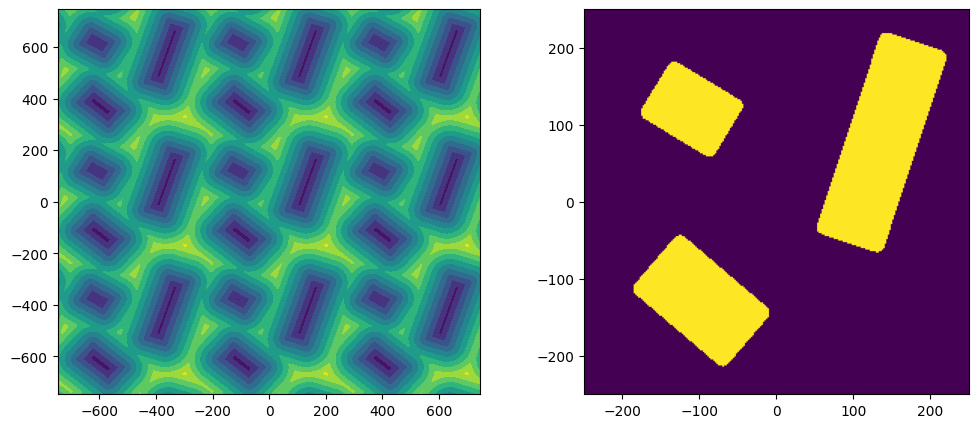

In [4]:
import torch

periods= 3

x1 = torch.linspace(-periods*canvas.Lx/2, periods*canvas.Lx/2, 300)
y1 = torch.linspace(-periods*canvas.Ly/2, periods*canvas.Ly/2, 300)

y, x = torch.meshgrid(y1, x1)

sdf = result.unit_cells[5].sdf(x, y)
im = result.unit_cells[5].mask_numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(sdf.detach().numpy(), origin='lower', extent=(-periods*canvas.Lx/2, periods*canvas.Lx/2, -periods*canvas.Ly/2, periods*canvas.Ly/2), levels=10)

plt.subplot(1, 2, 2)
plt.imshow(im, origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))

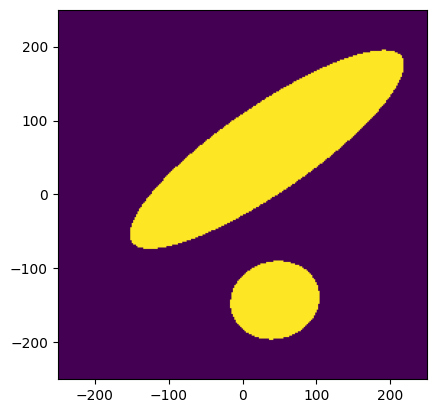

In [20]:
plt.imshow(result.unit_cells[5].mask_numpy(), origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))